In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded=files.upload()

Saving student_performance_dataset.csv to student_performance_dataset.csv


In [6]:
df=pd.read_csv("/content/student_performance_dataset.csv")

In [7]:
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


In [10]:
df.describe()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,708.000000,708.000000,708.000000,708.000000
mean,26.132768,78.107722,77.871469,58.771186
std,8.877727,13.802802,14.402739,6.705877
min,10.000000,50.116970,50.000000,50.000000
25%,19.000000,67.550094,65.000000,52.000000
50%,27.000000,79.363046,79.000000,59.500000
75%,34.000000,89.504232,91.000000,64.000000
max,39.000000,99.967675,100.000000,77.000000


In [11]:
df.isnull()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
703,False,False,False,False,False,False,False,False,False,False
704,False,False,False,False,False,False,False,False,False,False
705,False,False,False,False,False,False,False,False,False,False
706,False,False,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Study_Hours_per_Week,0
Attendance_Rate,0
Past_Exam_Scores,0
Parental_Education_Level,0
Internet_Access_at_Home,0
Extracurricular_Activities,0
Final_Exam_Score,0
Pass_Fail,0


In [13]:
def grade(score):
    if score > 70:
        return "A"
    elif score > 60:
        return "B"
    elif score > 50:
        return "C"
    else:
        return "Below C"

df["Category"] = df["Final_Exam_Score"].apply(grade)

print(df[["Final_Exam_Score","Category"]].head())

   Final_Exam_Score Category
0                63        B
1                50  Below C
2                55        C
3                65        B
4                70        B


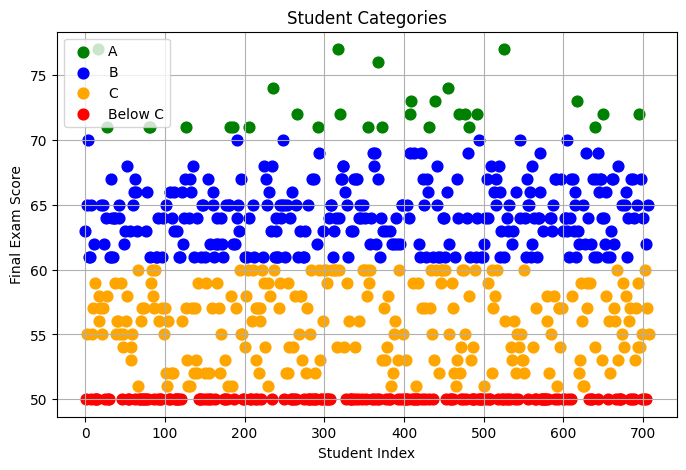

In [14]:
colors = {
    "A":"green",
    "B":"blue",
    "C":"orange",
    "Below C":"red"
}

plt.figure(figsize=(8,5))

for cat in colors:
    data = df[df["Category"]==cat]
    plt.scatter(
        data.index,
        data["Final_Exam_Score"],
        color=colors[cat],
        label=cat,
        s=60
    )

plt.title("Student Categories")
plt.xlabel("Student Index")
plt.ylabel("Final Exam Score")
plt.legend()
plt.grid(True)
plt.show()

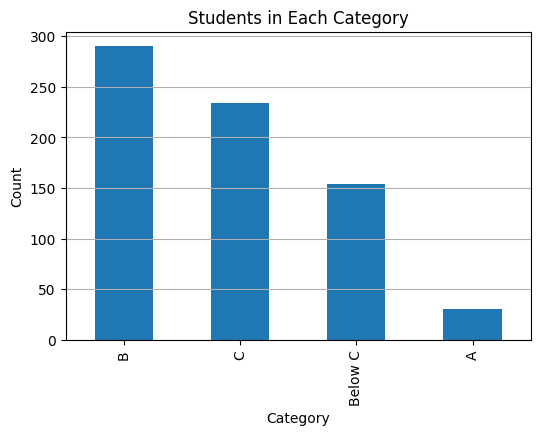

In [15]:
df["Category"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Students in Each Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.grid(axis="y")
plt.show()

In [18]:
from sklearn.svm import SVC

# Input and Output
X = df[["Final_Exam_Score"]]
y = df["Category"]

# Create SVM Model
model = SVC(kernel='linear')

# Train Model
model.fit(X, y)

SVC(kernel='linear')

In [22]:
score = float(input("Enter Final Exam Score: "))

prediction = model.predict([[score]])

print("Predicted Category:", prediction[0])

Enter Final Exam Score: 60
Predicted Category: C


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Enter Final Exam Score: 70


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Predicted Category: B


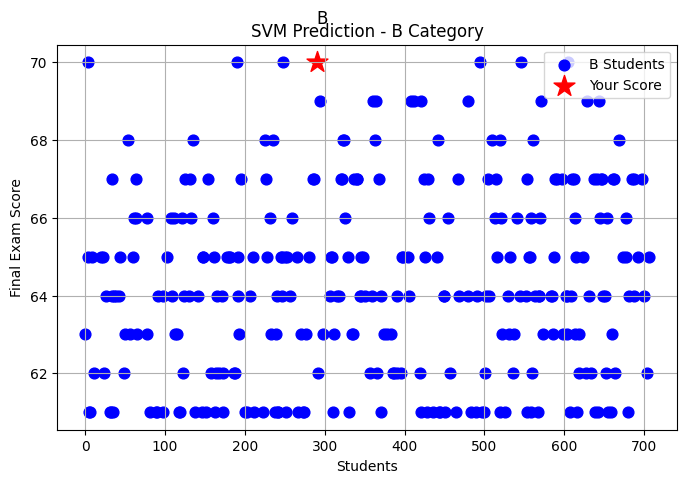

In [21]:
score = float(input("Enter Final Exam Score: "))

# Predict category
prediction = model.predict([[score]])
predicted_category = prediction[0]

print("Predicted Category:", predicted_category)

import matplotlib.pyplot as plt

# Filter only the predicted category
filtered_df = df[df["Category"] == predicted_category]

plt.figure(figsize=(8,5))

# Plot only that category
plt.scatter(
    filtered_df.index,
    filtered_df["Final_Exam_Score"],
    color="blue",
    s=60,
    label=f"{predicted_category} Students"
)

# Plot the entered score
plt.scatter(
    len(filtered_df),
    score,
    color="red",
    marker="*",
    s=250,
    label="Your Score"
)

plt.text(
    len(filtered_df),
    score + 1,
    f"{predicted_category}",
    fontsize=12
)

plt.title(f"SVM Prediction - {predicted_category} Category")
plt.xlabel("Students")
plt.ylabel("Final Exam Score")
plt.legend()
plt.grid(True)

plt.show()